# Advanced Techniques (1): Building a Stronger Baseline

In `baseline.ipynb` we trained a simple model and produced a valid `submission.csv`. Here we go one step further: try several feature candidates, compare models under identical conditions, and produce a stronger submission.

**A note on the domain.** The data comes from the NFL Combine — a yearly event where American-football prospects are measured and timed before professional teams choose ("draft") them. Each row is one prospect; the columns are physical measurements (height, weight) and athletic-drill results (a 40-yard sprint, two jumps, two agility runs, a bench-press test). You do **not** need to follow American football to do well here, but it helps to anchor your thinking in a sport or activity you *do* know: which measurements would *you* expect to separate the players a team picks from the ones it passes on?

Keep in mind what we are really building: a model that ranks *unseen* prospects well. The `submission.csv` is only how that model is scored — the actual work is deciding which features and which model earn their place.

**Task**: predict the probability that a prospect is **Drafted** (`1` = drafted, `0` = not drafted).  
**Evaluation metric**: ROC-AUC.

The workflow throughout:

> Form a hypothesis → change one feature or model → evaluate with cross-validation → compare → decide whether to keep it

## Connection to Previous Lectures

In this notebook, we apply ideas from the previous lectures to a real competition dataset.

- From **Supervised Learning**, we use classification models to predict whether a player will be drafted.
- From **Model Evaluation**, we evaluate models with **ROC-AUC** instead of accuracy.
- From **Feature Engineering**, we transform raw columns into model-friendly features.
- From **Cross-Validation**, we compare feature sets and models using the same validation strategy.


## Contents

1. Setup
2. Load the data
3. Understand the data
4. Feature candidates and preprocessing
5. Compare feature sets
6. Compare models
7. Ensemble preview
8. Create the submission file
9. Wrap-up


## 1. Setup

### 1.1 Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)


In [2]:
# Some environments may not ship LightGBM. Install it quietly if needed.
!pip install -q lightgbm

### 1.2 Connect with Google Drive

In [3]:
# If you are using Google Colaboratory, run this cell as well.
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Next, move to the folder that contains this notebook and the `input/` folder.

In [ ]:
# Specify the directory where this notebook is located after %cd.
%cd "/content/drive/MyDrive/WhereThisNotebookIsLocated"

Run the cell below to check the path is correct.

In [8]:
from pathlib import Path

WORK_DIR = Path.cwd()
PATH = WORK_DIR / 'input'
train_file = PATH / 'train.csv'
test_file = PATH / 'test.csv'
sample_sub_file = PATH / 'sample_submission.csv'

if train_file.exists() and test_file.exists() and sample_sub_file.exists():
    print('All required files exist and the path is set correctly.')
else:
    print('Some files are missing or the path is not set correctly.')


All required files exist and the path is set correctly.


## 2. Load the data

**IMPORTANT:** Whenever you change a feature, a preprocessing step, or a model, re-run **every cell from this data-loading cell downward** so that `train_raw` and `test_raw` are rebuilt from the original files. Many strange errors come from a stale DataFrame left over from a previous run.

In [9]:
train = pd.read_csv(train_file)
test = pd.read_csv(test_file)
sample_sub = pd.read_csv(sample_sub_file)

# In later sections, we create multiple feature matrices from the same starting point.
train_raw = train.copy()
test_raw = test.copy()

print(f'train: {train.shape}, test: {test.shape}, sample_sub: {sample_sub.shape}')


train: (2781, 16), test: (696, 15), sample_sub: (696, 2)


In [10]:
train.head()

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                2781 non-null   int64  
 1   Year              2781 non-null   int64  
 2   Age               2346 non-null   float64
 3   School            2781 non-null   object 
 4   Height            2781 non-null   float64
 5   Weight            2781 non-null   float64
 6   Sprint_40yd       2636 non-null   float64
 7   Vertical_Jump     2227 non-null   float64
 8   Bench_Press_Reps  2060 non-null   float64
 9   Broad_Jump        2200 non-null   float64
 10  Agility_3cone     1811 non-null   float64
 11  Shuttle           1869 non-null   float64
 12  Player_Type       2781 non-null   object 
 13  Position_Type     2781 non-null   object 
 14  Position          2781 non-null   object 
 15  Drafted           2781 non-null   float64
dtypes: float64(10), int64(2), object(4)
memory

## 3. Understand the data

We look at the data only where it changes a modeling decision: missing values, target balance, feature direction and scale, and draft rate by category. Each check exists to justify a feature idea later, not to make a plot for its own sake.

### 3.1 Missing values

Which columns have missing values, and how often? Most models cannot train on gaps, so we will have to fill them — but note first that *whether* a value is missing may itself be a signal worth keeping.

In [12]:
# Question: which columns have missing values, and how often?
missing_rate = train_raw.isna().mean()          # fraction missing per column
missing_count = train_raw.isna().sum()           # number missing per column

missing_summary = pd.DataFrame({
    'missing_rate': missing_rate,
    'missing_count': missing_count,
})
missing_summary = missing_summary[missing_summary['missing_count'] > 0]
missing_summary = missing_summary.sort_values('missing_rate', ascending=False)
missing_summary

,missing_rate,missing_count
Agility_3cone,0.348795,970
Shuttle,0.327940,912
Bench_Press_Reps,0.259259,721
Broad_Jump,0.208918,581
Vertical_Jump,0.199209,554
Age,0.156419,435
Sprint_40yd,0.052140,145


**Findings:**
- Several combine drills (`Agility_3cone`, `Bench_Press_Reps`, `Shuttle`, `Broad_Jump`, `Vertical_Jump`) are missing for many players — some more than half the time.
- Missingness here is unlikely to be random: it may reflect injury, position, or which drills a player chose to skip.

### 3.2 Target balance

How common is each class? When one class dominates, accuracy flatters a model that just predicts the majority — which is why this competition scores *ranking* (ROC-AUC) instead.

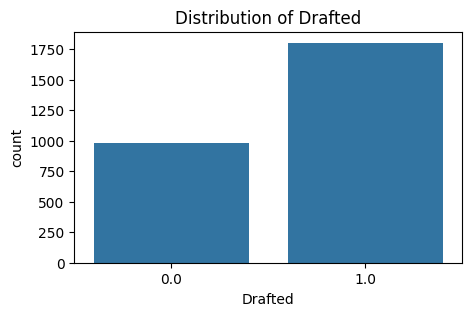

,proportion
Drafted,
1.0,64.83
0.0,35.17


In [13]:
plt.figure(figsize=(5, 3))
sns.countplot(data=train_raw, x='Drafted')
plt.title('Distribution of Drafted')
plt.show()

(train_raw['Drafted'].value_counts(normalize=True) * 100).round(2)

**Findings:**
- The target is imbalanced: more players are drafted than undrafted in this sample.
- The competition's metric is **ROC-AUC**, which scores how well the model *ranks* players rather than the labels it assigns.

### 3.3 Numeric features

What does each numeric column mean, and which direction is "good"? Build a feature without checking this and you can easily point it the wrong way.

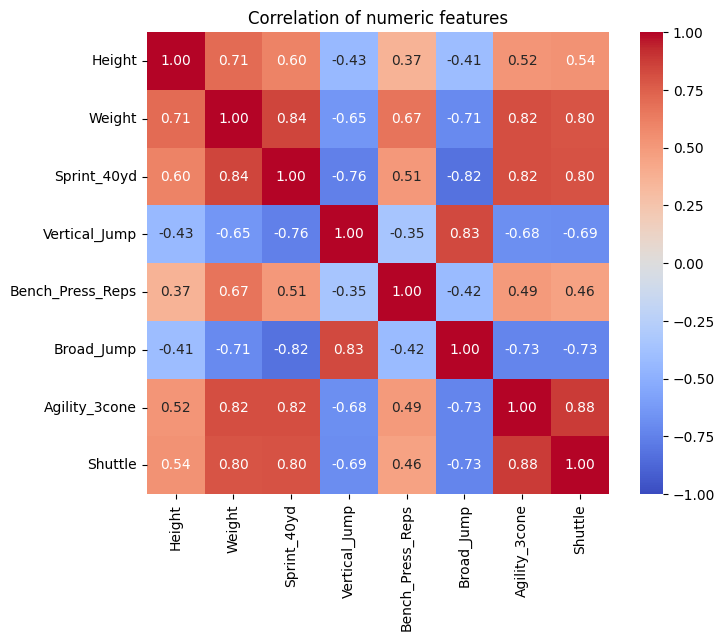

In [14]:
num_cols_for_plot = [
    'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
    'Broad_Jump', 'Agility_3cone', 'Shuttle'
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    train_raw[num_cols_for_plot].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True
)
plt.title('Correlation of numeric features')
plt.show()

**Findings:**
- `Sprint_40yd`, `Agility_3cone`, and `Shuttle` are *times*, so a smaller value is the better result.
- Jumps and bench-press reps run the other way: a larger value is the better result.

### 3.4 Draft rate by category

Does the draft rate depend on a player's position or type? If it does, these string columns carry signal — and will have to become numbers before a model can use them.

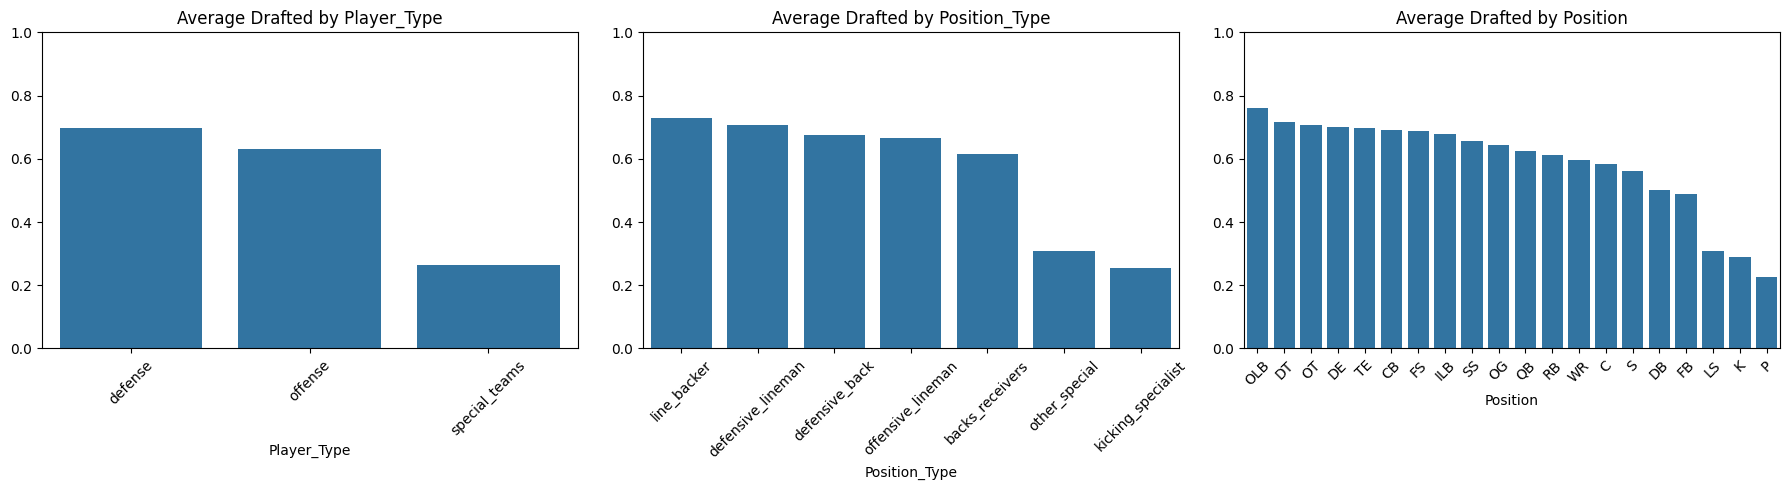

In [15]:
cat_cols_for_plot = ['Player_Type', 'Position_Type', 'Position']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, c in zip(axes, cat_cols_for_plot):
    draft_rate = train_raw.groupby(c)['Drafted'].mean().sort_values(ascending=False)
    sns.barplot(x=draft_rate.index, y=draft_rate.values, ax=ax)
    ax.set_title(f'Average Drafted by {c}')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Findings:**
- The bars are far from flat: draft rate clearly differs across `Position`, `Player_Type`, and `Position_Type`.
- `School` takes many distinct values, and most schools appear only a handful of times.

**Questions to think about:**
- A model cannot read raw strings. How would you turn `Position` into something numeric without inventing a fake ordering?
- `School` has hundreds of values. What goes wrong if you one-hot encode it, and what is a lighter alternative?
- Which other columns (`Age`, `Year`, `Weight`) might relate to `Drafted`, and what plot would show it?

## 4. Feature candidates and preprocessing

The baseline used a minimal feature set. Here we add a few candidate features and test each the same way: fix the model and the CV split, add one candidate, compare OOF AUC. Changing one thing at a time is what lets us credit a score change to the feature rather than to luck.

We intentionally keep the ideas simple here. Richer athletic features built from the combine measurements come in a later tutorial.

The goal of this notebook is not to invent many clever features at once. It is to practise testing one feature idea at a time in a controlled way.

### 4.1 Feature ideas in this notebook

We compare three simple feature ideas, each a small hypothesis about what might separate drafted prospects.

| Feature idea | Description | Rationale |
|---|---|---|
| `BMI` | Combine height and weight into a body-size feature. | Body shape may matter in a way that height and weight on their own do not capture. |
| `School_CE` | Apply count encoding to `School`. | How often a school appears may track program size or scouting visibility — though it says nothing about draft chance directly. |
| Missing indicators | Flag whether a physical-test value was originally missing. | A skipped drill may relate to injury, position, or how a prospect was being evaluated. |

None of these is obviously good or bad by argument alone, so Section 5 puts all three through the same comparison and lets the validation score decide.

### 4.2 How to use `School`

`School` is a categorical feature. Before choosing an encoding method, we first check how many unique schools appear in the training data and how often each school appears.

If many schools appear only a few times, one-hot encoding can create many sparse columns. In that case, a simpler encoding method may be more appropriate for this notebook.

Number of unique schools: 236
Top 10 schools:


,count
School,
Alabama,73
LSU,70
USC,63
Ohio St.,59
Clemson,57
Florida St.,57
Miami (FL),54
Oklahoma,54
Georgia,54


,minimum_appearances,number_of_schools
0,1,236
1,2,171
2,3,138
3,5,110
4,10,85
5,20,48
6,30,35
7,50,10


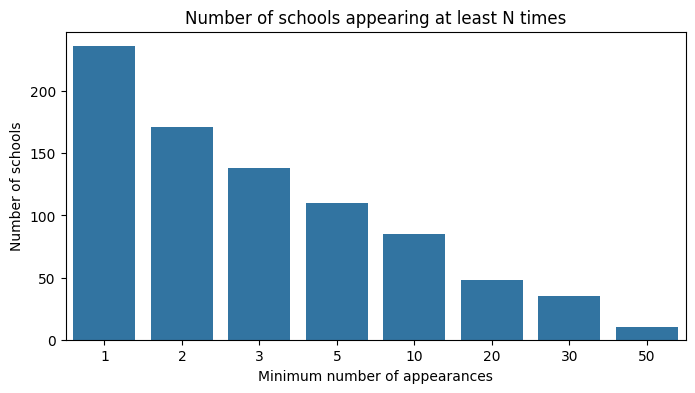

In [16]:
school_counts = train_raw['School'].value_counts()

print('Number of unique schools:', school_counts.shape[0])
print('Top 10 schools:')
display(school_counts.head(10).to_frame('count'))

# How many schools survive if we require at least N appearances?
thresholds = [1, 2, 3, 5, 10, 20, 30, 50]
schools_per_threshold = []
for t in thresholds:
    n_schools = (school_counts >= t).sum()
    schools_per_threshold.append(n_schools)

school_dist = pd.DataFrame({
    'minimum_appearances': thresholds,
    'number_of_schools': schools_per_threshold,
})
display(school_dist)

plt.figure(figsize=(8, 4))
sns.barplot(data=school_dist, x='minimum_appearances', y='number_of_schools')
plt.title('Number of schools appearing at least N times')
plt.xlabel('Minimum number of appearances')
plt.ylabel('Number of schools')
plt.show()

Most schools appear only a few times — 65 of the 236 schools show up just once — so one-hot encoding would add hundreds of almost-empty columns. Instead we use **count encoding**: each school becomes the number of times it appears in the training data. `Alabama` appears 73 times, so every Alabama prospect gets `73`; a school seen once gets `1`; a school that appears only in the test set gets `0`.

Note what this is: a frequency, not a draft rate. It may track program size or scouting visibility, but nothing about it guarantees a higher draft chance. We avoid target-based encoding here because doing it without leakage means re-encoding inside each fold — heavier than this notebook needs. Whether `School_CE` actually earns its place is left to the comparison in Section 5.

We name the target, the ID, the high-cardinality column, the numeric columns to impute, and the categorical columns to encode in one place so the preprocessing function stays readable.

In [17]:
TARGET = 'Drafted'
ID_COL = 'Id'
HIGH_CARDINALITY_COL = 'School'

NUMERIC_MISSING_COLS = [
    'Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
    'Broad_Jump', 'Agility_3cone', 'Shuttle'
]

CATEGORICAL_COLS = ['Player_Type', 'Position_Type', 'Position']

#### Column groups used in preprocessing

`TARGET` is what we predict; `ID_COL` identifies a row and is never a feature; `HIGH_CARDINALITY_COL` is `School`; `NUMERIC_MISSING_COLS` need imputing; `CATEGORICAL_COLS` need encoding. Low-cardinality categoricals get a simple integer mapping, `School` gets count encoding.

Putting preprocessing in a function means every candidate feature set starts from the same raw data — a fair comparison. The `use_bmi`, `use_school_ce`, and `use_missing_indicators` flags switch each idea on or off.

In [18]:
def prepare_features(
    train_raw,
    test_raw,
    use_bmi=False,
    use_school_ce=False,
    use_missing_indicators=False,
):
    # Create train/test feature matrices from the raw data.
    train = train_raw.copy()
    test = test_raw.copy()

    # Candidate 1: BMI.
    # Combine height and weight into a body-size feature.
    # In this dataset, Height is in meters and Weight is in kilograms.
    if use_bmi:
        train['BMI'] = train['Weight'] / (train['Height'] ** 2)
        test['BMI'] = test['Weight'] / (test['Height'] ** 2)

    # Candidate 2: School Count Encoding.
    # School has many unique values, so it is difficult to use directly.
    # We convert each school into its frequency in the training data.
    # Schools that appear only in the test set are encoded as 0.
    if use_school_ce:
        school_counts = train[HIGH_CARDINALITY_COL].value_counts()
        train['School_CE'] = train[HIGH_CARDINALITY_COL].map(school_counts).fillna(0)
        test['School_CE'] = test[HIGH_CARDINALITY_COL].map(school_counts).fillna(0)

    # Candidate 3: missing-value indicators.
    # Create these before imputation so that missingness information is not lost.
    if use_missing_indicators:
        for c in NUMERIC_MISSING_COLS:
            train[f'{c}_missing'] = train[c].isna().astype(int)
            test[f'{c}_missing'] = test[c].isna().astype(int)

    # Apply mean imputation to numeric columns with missing values.
    # Fill test-set missing values with the train mean, not the test mean.
    for c in NUMERIC_MISSING_COLS:
        mean_value = train[c].mean()
        train[c] = train[c].fillna(mean_value)
        test[c] = test[c].fillna(mean_value)

    # Robustly label-encode low-cardinality categorical columns.
    # Categories that appear only in the test set are encoded as -1.
    for c in CATEGORICAL_COLS:
        categories = train[c].astype(str).unique()
        mapping = {cat: i for i, cat in enumerate(categories)}

        train[c] = train[c].astype(str).map(mapping).astype(int)
        test[c] = test[c].astype(str).map(mapping).fillna(-1).astype(int)

    # Exclude the identifier, target, and raw School from the features.
    # If we use School, we use it as School_CE, not as a raw string.
    drop_cols = [ID_COL, HIGH_CARDINALITY_COL, TARGET]
    feature_cols = [c for c in train.columns if c not in drop_cols]

    X = train[feature_cols].copy()
    y = train[TARGET].astype(int)
    X_test = test[feature_cols].copy()

    return X, y, X_test, feature_cols


#### Two things to notice in the function

Order matters in two places. Missing-value **indicators are created before imputation** — once a gap is filled with a mean, you can no longer tell it was missing. And test-set gaps are filled with the **training** mean: computing any statistic from the test set would leak information the model will not have at prediction time.

### 4.5 Predicted probabilities, not labels

Because the metric is ROC-AUC, what matters is *ranking*, not the hard `0/1` label a threshold would produce. ROC-AUC asks a simple question: if you pick one drafted and one undrafted prospect at random, how often does the model score the drafted one higher?

A quick worked example. Suppose three prospects get these predicted probabilities of being drafted:

- Player A — `0.80`
- Player B — `0.55`
- Player C — `0.20`

If A and B were really drafted and C was not, it is the *order* (A and B above C) that earns a high ROC-AUC — the exact numbers, and any cutoff such as `0.5`, do not matter. That is why every model below is read through `predict_proba` and never collapsed into hard labels.

### 4.6 Cross-validation helper

A single train/validation split can be lucky or unlucky. **5-fold stratified cross-validation** rotates through five folds, so every row is predicted once by a model that did not train on it. Collecting those **out-of-fold (OOF)** predictions gives one AUC over the whole training set. Stratification keeps the drafted/undrafted ratio steady across folds.

In [19]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def cv_fit_predict(make_model, X, y, X_test=None, needs_scaling=False):
    # Run 5-fold CV and optionally create fold-averaged test predictions.
    oof = np.zeros(len(X))
    test_pred = np.zeros(len(X_test)) if X_test is not None else None
    fold_aucs = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_va = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy()
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        if needs_scaling:
            scaler = StandardScaler()
            X_tr = pd.DataFrame(scaler.fit_transform(X_tr), columns=X.columns, index=X_tr.index)
            X_va = pd.DataFrame(scaler.transform(X_va), columns=X.columns, index=X_va.index)
            X_te = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index) if X_test is not None else None
        else:
            X_te = X_test

        model = make_model()
        model.fit(X_tr, y_tr)

        va_pred = model.predict_proba(X_va)[:, 1]
        oof[va_idx] = va_pred

        fold_auc = roc_auc_score(y_va, va_pred)
        fold_aucs.append(fold_auc)

        if X_test is not None:
            test_pred += model.predict_proba(X_te)[:, 1] / skf.n_splits

        print(f'Fold {fold}: AUC = {fold_auc:.4f}')

    oof_auc = roc_auc_score(y, oof)
    print(f'OOF AUC: {oof_auc:.4f}')

    return oof, test_pred, oof_auc, fold_aucs


The helper also averages each fold's test predictions. Because every fold trains a slightly different model, averaging is usually a little steadier than trusting any single fold.

**Questions to think about:**
- `prepare_features` fills numeric gaps with the **train** mean, then applies it to the test set. Why must the test set use the *train* statistic rather than its own?
- Would median or model-based imputation change the results here?
- `School_CE` deliberately ignores the target to stay leakage-safe. What would target/mean encoding add, and how would you keep it leakage-free *inside each fold*?

## 5. Compare feature sets

A reasonable-looking feature can still *hurt* — by adding noise, by duplicating information already present, or by not suiting the model. So we run an ablation: same Random Forest, same 5-fold split, one feature change at a time. Comparing `Base + School_CE` on its own, for example, tells us whether `School` carries any signal at all.

### 5.1 Fixed model for feature comparison

We hold the model fixed at Random Forest while the features vary. It is convenient here: it handles nonlinearities and mixed numeric/encoded columns, needs no scaling, and is fast enough to refit many times. Fixing it means any score change comes from the features, not the model.

In [20]:
from sklearn.ensemble import RandomForestClassifier


def make_rf_for_feature_comparison():
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=3,
        random_state=SEED,
        n_jobs=-1,
    )

### 5.2 Run the comparison

Each feature set runs through the same Random Forest and the same 5-fold CV. Treat tiny decimal differences with suspicion — a *stable* improvement is the signal worth acting on.

In [21]:
feature_configs = [
    ('Base', dict(use_bmi=False, use_school_ce=False, use_missing_indicators=False)),
    ('Base + BMI', dict(use_bmi=True, use_school_ce=False, use_missing_indicators=False)),
    ('Base + School_CE', dict(use_bmi=False, use_school_ce=True, use_missing_indicators=False)),
    ('Base + missing indicators', dict(use_bmi=False, use_school_ce=False, use_missing_indicators=True)),
    ('Base + BMI + School_CE + missing indicators', dict(use_bmi=True, use_school_ce=True, use_missing_indicators=True)),
]

feature_rows = []
prepared_features = {}

for name, cfg in feature_configs:
    print('\n' + '=' * 80)
    print(name)
    print('=' * 80)

    X_fs, y, X_test_fs, feature_cols = prepare_features(train_raw, test_raw, **cfg)
    oof, test_pred, auc, fold_aucs = cv_fit_predict(
        make_rf_for_feature_comparison,
        X_fs,
        y,
        X_test_fs,
        needs_scaling=False,
    )

    feature_rows.append({
        'feature_set': name,
        'n_features': len(feature_cols),
        'OOF AUC': auc,
        'fold_auc_mean': np.mean(fold_aucs),
        'fold_auc_std': np.std(fold_aucs),
    })
    prepared_features[name] = {
        'X': X_fs,
        'y': y,
        'X_test': X_test_fs,
        'feature_cols': feature_cols,
    }

feature_comparison = pd.DataFrame(feature_rows)
feature_comparison


Base
Fold 1: AUC = 0.7984
Fold 2: AUC = 0.8382
Fold 3: AUC = 0.8363
Fold 4: AUC = 0.7751
Fold 5: AUC = 0.8355
OOF AUC: 0.8158

Base + BMI
Fold 1: AUC = 0.7979
Fold 2: AUC = 0.8370
Fold 3: AUC = 0.8403
Fold 4: AUC = 0.7885
Fold 5: AUC = 0.8301
OOF AUC: 0.8180

Base + School_CE
Fold 1: AUC = 0.8000
Fold 2: AUC = 0.8441
Fold 3: AUC = 0.8342
Fold 4: AUC = 0.7820
Fold 5: AUC = 0.8356
OOF AUC: 0.8183

Base + missing indicators
Fold 1: AUC = 0.8023
Fold 2: AUC = 0.8469
Fold 3: AUC = 0.8464
Fold 4: AUC = 0.7787
Fold 5: AUC = 0.8419
OOF AUC: 0.8223

Base + BMI + School_CE + missing indicators
Fold 1: AUC = 0.7945
Fold 2: AUC = 0.8494
Fold 3: AUC = 0.8406
Fold 4: AUC = 0.7934
Fold 5: AUC = 0.8389
OOF AUC: 0.8225


,feature_set,n_features,OOF AUC,fold_auc_mean,fold_auc_std
0,Base,13,0.815822,0.816726,0.025558
1,Base + BMI,14,0.817952,0.818754,0.021333
2,Base + School_CE,14,0.818290,0.819178,0.023939
3,Base + missing indicators,20,0.822318,0.823249,0.027811
4,Base + BMI + School_CE + missing indicators,22,0.822479,0.823348,0.024275


#### How to read the feature comparison table

The top row is the best result *for this model, split, and seed* — not a universal verdict. Read it for which simple ideas are worth carrying forward.

### 5.3 Visualize the feature comparison

The chart makes the relative gaps easier to read than the table. A feature set that lands *below* Base is still informative — it is a reason not to trust that idea.

These plots are quick diagnostics for *us*. When a chart goes into your own write-up, treat it as a separate craft: one clear takeaway, labelled axes, and a title that states the point — not just whatever the default settings produce.

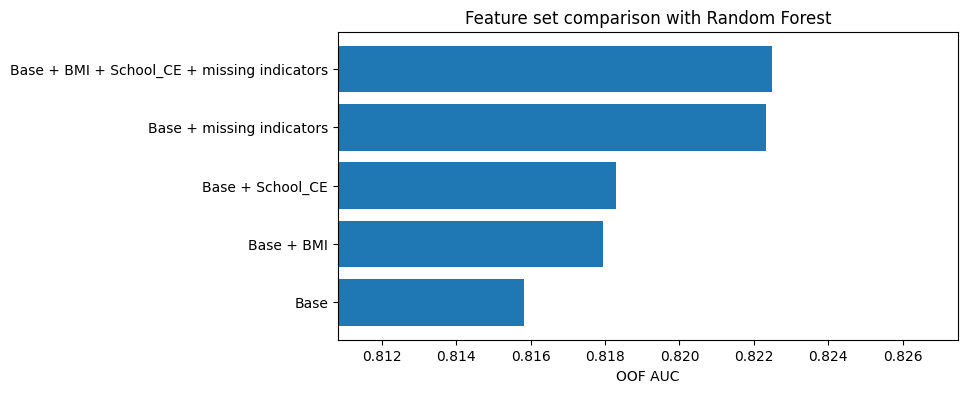

,feature_set,n_features,OOF AUC,fold_auc_mean,fold_auc_std
4,Base + BMI + School_CE + missing indicators,22,0.8225,0.8233,0.0243
3,Base + missing indicators,20,0.8223,0.8232,0.0278
2,Base + School_CE,14,0.8183,0.8192,0.0239
1,Base + BMI,14,0.8180,0.8188,0.0213
0,Base,13,0.8158,0.8167,0.0256


In [22]:
feature_comparison_sorted = feature_comparison.sort_values('OOF AUC', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feature_comparison_sorted['feature_set'], feature_comparison_sorted['OOF AUC'])
plt.xlabel('OOF AUC')
plt.title('Feature set comparison with Random Forest')
plt.xlim(feature_comparison['OOF AUC'].min() - 0.005, feature_comparison['OOF AUC'].max() + 0.005)
plt.show()

feature_comparison.sort_values('OOF AUC', ascending=False).style.format({
    'OOF AUC': '{:.4f}',
    'fold_auc_mean': '{:.4f}',
    'fold_auc_std': '{:.4f}',
})

### 5.4 Choose the feature set for the next step

We carry forward the feature set with the best OOF AUC — a validation-based choice, not a leaderboard one. Chasing the public leaderboard across many submissions invites overfitting to it; cross-validation lets us settle most decisions before we ever submit.

**Questions to think about:**
- The "best" feature set is best only for *this* model, *this* split, and *this* seed. How stable is the ranking if you change `SEED`?
- A feature that helps Random Forest may not help a linear model. Will your choice survive Section 6?
- Are the AUC gaps larger than `fold_auc_std`? If not, how much should you trust them?

In [23]:
selected_feature_set = feature_comparison.sort_values('OOF AUC', ascending=False).iloc[0]['feature_set']
print('Selected feature set:', selected_feature_set)

X = prepared_features[selected_feature_set]['X']
y = prepared_features[selected_feature_set]['y']
X_test = prepared_features[selected_feature_set]['X_test']
feature_cols = prepared_features[selected_feature_set]['feature_cols']

print(f'Number of selected features: {len(feature_cols)}')
print(feature_cols)

Selected feature set: Base + BMI + School_CE + missing indicators
Number of selected features: 22
['Year', 'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'Player_Type', 'Position_Type', 'Position', 'BMI', 'School_CE', 'Age_missing', 'Sprint_40yd_missing', 'Vertical_Jump_missing', 'Bench_Press_Reps_missing', 'Broad_Jump_missing', 'Agility_3cone_missing', 'Shuttle_missing']


## 6. Compare models

With the feature set fixed, we now vary the model. Logistic Regression fits a mostly linear boundary (and needs scaled inputs); Random Forest and LightGBM capture nonlinear patterns straight from thresholds. A feature set need not suit every model equally, so comparing families separates "good features" from "good model for these features."

In [24]:
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

model_specs = [
    (
        'Logistic Regression',
        lambda: LogisticRegression(max_iter=2000, random_state=SEED),
        True,
    ),
    (
        'Random Forest',
        lambda: RandomForestClassifier(
            n_estimators=500,
            max_depth=10,
            min_samples_leaf=3,
            random_state=SEED,
            n_jobs=-1,
        ),
        False,
    ),
    (
        'LightGBM',
        lambda: LGBMClassifier(
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,
        ),
        False,
    ),
]

model_rows = []
oof_predictions = {}
test_predictions = {}

for model_name, make_model, needs_scaling in model_specs:
    print('\n' + '=' * 80)
    print(model_name)
    print('=' * 80)

    oof, test_pred, auc, fold_aucs = cv_fit_predict(
        make_model,
        X,
        y,
        X_test,
        needs_scaling=needs_scaling,
    )

    oof_predictions[model_name] = oof
    test_predictions[model_name] = test_pred
    model_rows.append({
        'model': model_name,
        'OOF AUC': auc,
        'fold_auc_mean': np.mean(fold_aucs),
        'fold_auc_std': np.std(fold_aucs),
    })

model_comparison = pd.DataFrame(model_rows).sort_values('OOF AUC', ascending=False)
model_comparison.style.format({
    'OOF AUC': '{:.4f}',
    'fold_auc_mean': '{:.4f}',
    'fold_auc_std': '{:.4f}',
})


Logistic Regression
Fold 1: AUC = 0.7982
Fold 2: AUC = 0.8446
Fold 3: AUC = 0.8456
Fold 4: AUC = 0.7975
Fold 5: AUC = 0.8307
OOF AUC: 0.8231

Random Forest
Fold 1: AUC = 0.7948
Fold 2: AUC = 0.8496
Fold 3: AUC = 0.8434
Fold 4: AUC = 0.7899
Fold 5: AUC = 0.8400
OOF AUC: 0.8229

LightGBM
Fold 1: AUC = 0.7886
Fold 2: AUC = 0.8286
Fold 3: AUC = 0.8150
Fold 4: AUC = 0.7753
Fold 5: AUC = 0.8316
OOF AUC: 0.8072


,model,OOF AUC,fold_auc_mean,fold_auc_std
0,Logistic Regression,0.8231,0.8233,0.0215
1,Random Forest,0.8229,0.8235,0.0257
2,LightGBM,0.8072,0.8078,0.0223


#### Interpreting the model comparison

Section 5 asked *which features*; Section 6 asks *which model for those features*. Holding one fixed while the other varies is what keeps each answer readable.

**Questions to think about:**
- Logistic Regression needs scaling; trees do not. Which other model families (XGBoost, CatBoost) might be worth adding to this comparison?
- Does the feature set chosen in Section 5 stay best for *every* model?
- Are the default hyperparameters fair to each model? (Tutorial 3 takes this up.)

## 7. Optional: a quick ensemble preview

This notebook is about comparing features and models with CV; ensembling gets a proper treatment in a later tutorial. As a preview, we simply average the model predictions and see what happens.

In [25]:
# Optional preview: simple average of all model predictions.
model_names = list(oof_predictions.keys())

ensemble_oof = np.mean([oof_predictions[m] for m in model_names], axis=0)
ensemble_test = np.mean([test_predictions[m] for m in model_names], axis=0)
ensemble_auc = roc_auc_score(y, ensemble_oof)

best_single_auc = model_comparison['OOF AUC'].max()

print('Models used in the ensemble:', model_names)
print(f'Best single-model OOF AUC:     {best_single_auc:.4f}')
print(f'Simple average ensemble AUC:   {ensemble_auc:.4f}')

Models used in the ensemble: ['Logistic Regression', 'Random Forest', 'LightGBM']
Best single-model OOF AUC:     0.8231
Simple average ensemble AUC:   0.8263


#### Interpreting the preview

If the average beats the best single model, the models are likely contributing different information; if it does worse, they may be too similar or one may be weak. We do not submit this average.

**Questions to think about:**
- Did the simple average help or hurt? Was that because the models are *diverse* or because one is *weak*?
- How would you measure model diversity *before* averaging? (Tutorial 4 explores this.)
- Would a weighted or rank average behave differently from the plain mean?

In [26]:
# For the final submission in this notebook, we use only single models.
# The ensemble above is optional and is not included in the submission candidates.
score_rows = []
submission_candidates = {}

for model_name in model_names:
    auc = roc_auc_score(y, oof_predictions[model_name])
    score_rows.append({'method': model_name, 'OOF AUC': auc})
    submission_candidates[model_name] = test_predictions[model_name]

score_table = pd.DataFrame(score_rows).sort_values('OOF AUC', ascending=False)
score_table.style.format({'OOF AUC': '{:.4f}'})

,method,OOF AUC
0,Logistic Regression,0.8231
1,Random Forest,0.8229
2,LightGBM,0.8072


## 8. Create the submission file

We submit the method with the best OOF AUC. That score is not the leaderboard, but it is the *same yardstick* applied to every candidate, so it is the fair basis for the choice — and a strong OOF AUC is evidence the ranking will hold up on prospects the model has never seen, which is the real goal. Treat any single leaderboard number cautiously and let cross-validation drive the decisions.

In [27]:
selected_method = score_table.iloc[0]['method']
print('Selected submission method:', selected_method)

test_pred = submission_candidates[selected_method]

Selected submission method: Logistic Regression


#### Pre-submission checks

A good validation score is encouraging, but it is not enough. Before submission, check the following.

- the number of rows in the file is correct
- the prediction column name is correct
- predicted probabilities are between 0 and 1
- row order follows `sample_submission.csv`

Many submission errors are formatting errors, not modeling errors.


### Saving the prediction as a CSV file [DO NOT CHANGE]

**WARNING**: Do not change the following cell unless you understand what it is doing.

The final CSV must exactly match the expected format. By using `sample_submission.csv`, we preserve the required row order and column structure. Here, we replace only the `Drafted` column with our predictions.


In [28]:
submission = pd.read_csv(sample_sub_file)
submission['Drafted'] = test_pred

out_dir = WORK_DIR / 'output'
out_dir.mkdir(exist_ok=True)

submission_path = out_dir / 'submission.csv'
submission.to_csv(submission_path, index=False)

print('Saved to:', submission_path)
submission.head()

Saved to: /content/drive/MyDrive/competition2026Apr/output/submission.csv


,Id,Drafted
0,2781,0.609206
1,2782,0.764079
2,2783,0.901929
3,2784,0.893113
4,2785,0.785240


## 9. Wrap-up

In this notebook we changed one thing at a time — a feature, then a model — and let cross-validation decide what was worth keeping.

The workflow worth carrying into your own submission is:

> Change one thing → evaluate with CV → compare → decide

It is slower than adding many ideas at once, but it is the only way to learn *which* idea actually helped.

**Questions to think about:**
- The next tutorial builds athletic "domain" features from these combine columns. Which raw columns would you combine, and in which direction?
- A later tutorial tunes a single strong model. Which settings do you expect to matter most?
- The final tutorial studies ensembling. When do you think combining models actually helps?

*If a cell raises an error, re-run everything from Section 2 so the raw data is rebuilt.*